In [1]:
# %% Cell 1 — Load libraries and cleaned data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

# Set a clean style for all plots
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 12

df = pd.read_parquet('../data/processed/cleaned.parquet')
df['date'] = pd.to_datetime(df['date'])

print(f"Loaded {len(df)} rows")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")

Loaded 5663 rows
Date range: 2010-07-30 to 2026-01-31


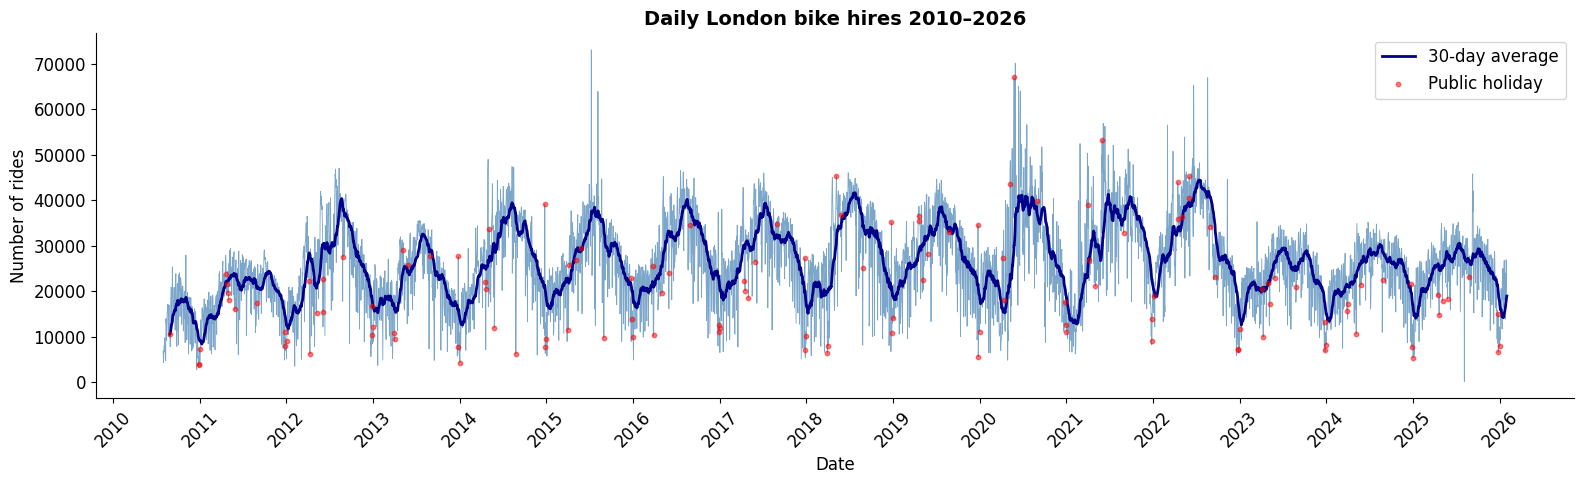

Plot 1 saved!


In [2]:
# %% Cell 2 — Plot 1: Daily rides over time
# This shows the full 15 year picture
# You can clearly see seasonal patterns every year
# and the overall growth trend

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(df['date'], df['rides'], 
        color='steelblue', linewidth=0.6, alpha=0.7)

# Add a 30-day rolling average line to show the trend more clearly
rolling = df.set_index('date')['rides'].rolling(30).mean()
ax.plot(rolling.index, rolling.values, 
        color='darkblue', linewidth=2, label='30-day average')

# Mark all holiday dates with a small red dot
holidays_df = df[df['is_holiday'] == 1]
ax.scatter(holidays_df['date'], holidays_df['rides'],
           color='red', s=10, alpha=0.5, zorder=5, label='Public holiday')

ax.set_title('Daily London bike hires 2010–2026', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Number of rides')
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../notebooks/plot_01_rides_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 1 saved!")

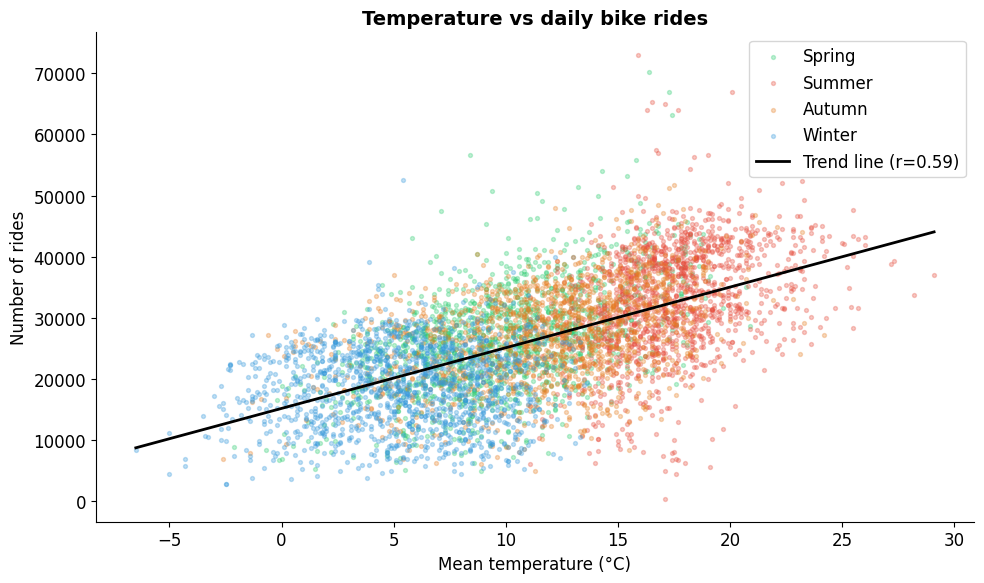

=== TEMPERATURE EFFECT ===
Slope: each +1°C = +994 rides per day
Correlation: r = 0.592
P-value: 0.000000 (significant)
R²: 0.351 (temperature explains 35.1% of variation in rides)


In [3]:
# %% Cell 3 — Plot 2: Temperature vs rides scatter plot
# This is your most important plot for the research question
# Each dot is one day — you should see a clear upward trend
# meaning warmer days = more rides

fig, ax = plt.subplots(figsize=(10, 6))

# Color each dot by season so you can see the seasonal pattern
season_colors = {
    'Spring': '#2ecc71',
    'Summer': '#e74c3c', 
    'Autumn': '#e67e22',
    'Winter': '#3498db'
}

for season, color in season_colors.items():
    mask = df['season_name'] == season
    ax.scatter(df.loc[mask, 'temp_mean'], 
               df.loc[mask, 'rides'],
               c=color, label=season, alpha=0.3, s=8)

# Add regression line
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df['temp_mean'], df['rides']
)
x_line = np.linspace(df['temp_mean'].min(), df['temp_mean'].max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, 'black', linewidth=2, 
        label=f'Trend line (r={r_value:.2f})')

ax.set_title('Temperature vs daily bike rides', fontsize=14, fontweight='bold')
ax.set_xlabel('Mean temperature (°C)')
ax.set_ylabel('Number of rides')
ax.legend()
plt.tight_layout()
plt.savefig('../notebooks/plot_02_temperature_vs_rides.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the key statistic
print(f"=== TEMPERATURE EFFECT ===")
print(f"Slope: each +1°C = +{slope:.0f} rides per day")
print(f"Correlation: r = {r_value:.3f}")
print(f"P-value: {p_value:.6f} ({'significant' if p_value < 0.05 else 'not significant'})")
print(f"R²: {r_value**2:.3f} (temperature explains {r_value**2*100:.1f}% of variation in rides)")

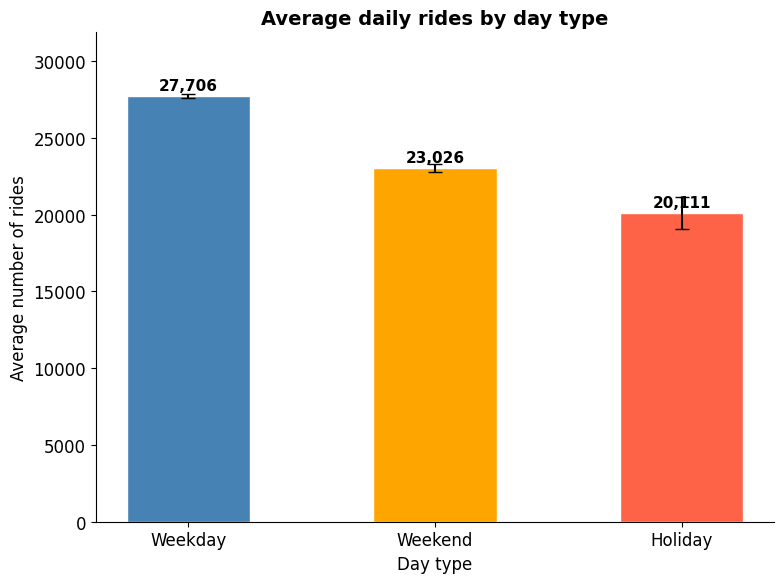

=== HOLIDAY EFFECT ===
Weekday: 27,706 average rides
Weekend: 23,026 average rides
Holiday: 20,111 average rides

Holidays have -27.4% rides compared to weekdays
T-test p-value: 0.000000 (significant)


In [4]:
# %% Cell 4 — Plot 3: Holiday effect bar chart
# Simple and clear — average rides on holidays vs weekends vs weekdays
# This directly answers the holiday part of your research question

day_type_avg = df.groupby('day_type')['rides'].agg(['mean', 'std', 'count'])
day_type_avg = day_type_avg.reindex(['Weekday', 'Weekend', 'Holiday'])

fig, ax = plt.subplots(figsize=(8, 6))

colors = ['steelblue', 'orange', 'tomato']
bars = ax.bar(day_type_avg.index, 
              day_type_avg['mean'],
              yerr=day_type_avg['std'] / np.sqrt(day_type_avg['count']),
              color=colors, edgecolor='white', 
              capsize=5, width=0.5)

# Add value labels on top of each bar
for bar, val in zip(bars, day_type_avg['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 200,
            f'{val:,.0f}', ha='center', va='bottom', 
            fontweight='bold', fontsize=11)

ax.set_title('Average daily rides by day type', fontsize=14, fontweight='bold')
ax.set_xlabel('Day type')
ax.set_ylabel('Average number of rides')
ax.set_ylim(0, day_type_avg['mean'].max() * 1.15)
plt.tight_layout()
plt.savefig('../notebooks/plot_03_holiday_effect.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the key statistics
print(f"=== HOLIDAY EFFECT ===")
for day_type in ['Weekday', 'Weekend', 'Holiday']:
    avg = day_type_avg.loc[day_type, 'mean']
    print(f"{day_type}: {avg:,.0f} average rides")

weekday_avg = day_type_avg.loc['Weekday', 'mean']
holiday_avg = day_type_avg.loc['Holiday', 'mean']
pct_diff = (holiday_avg - weekday_avg) / weekday_avg * 100
print(f"\nHolidays have {pct_diff:.1f}% rides compared to weekdays")

# T-test to confirm the difference is statistically significant
t_stat, p_val = stats.ttest_ind(
    df[df['day_type'] == 'Holiday']['rides'],
    df[df['day_type'] == 'Weekday']['rides']
)
print(f"T-test p-value: {p_val:.6f} ({'significant' if p_val < 0.05 else 'not significant'})")

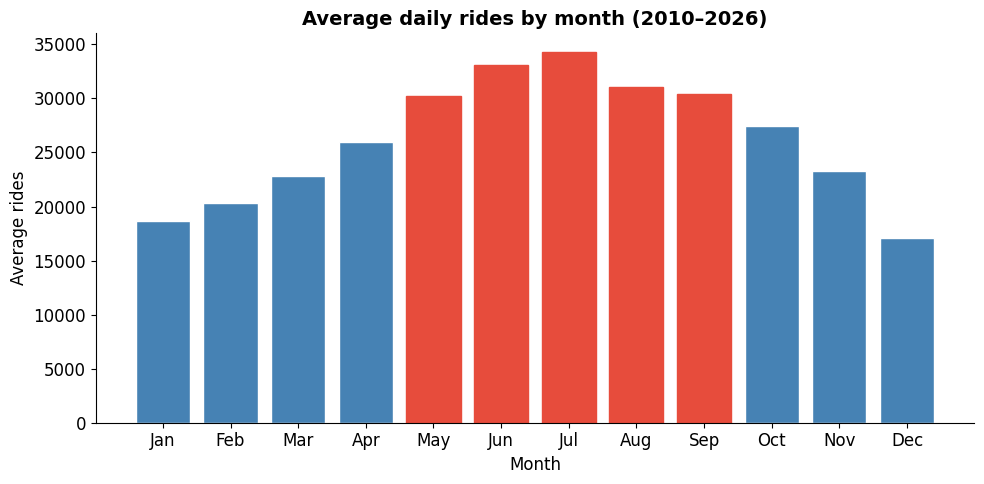

=== MONTHLY AVERAGES ===
Jan: 18,629
Feb: 20,326
Mar: 22,863
Apr: 25,957
May: 30,244
Jun: 33,082
Jul: 34,309
Aug: 31,034
Sep: 30,398
Oct: 27,422
Nov: 23,302
Dec: 17,132


In [5]:
# %% Cell 5 — Plot 4: Average rides by month
# Shows the seasonal pattern clearly across the year
# Expect a clear peak in summer months

monthly_avg = df.groupby('month')['rides'].mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(month_names, monthly_avg.values,
              color='steelblue', edgecolor='white')

# Color summer months differently to highlight peak season
summer_months = [5, 6, 7, 8, 9]  # index 4-8 = May-Sep
for i, bar in enumerate(bars):
    if i + 1 in summer_months:
        bar.set_color('#e74c3c')

ax.set_title('Average daily rides by month (2010–2026)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Average rides')
plt.tight_layout()
plt.savefig('../notebooks/plot_04_monthly_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== MONTHLY AVERAGES ===")
for month, avg in zip(month_names, monthly_avg.values):
    print(f"{month}: {avg:,.0f}")

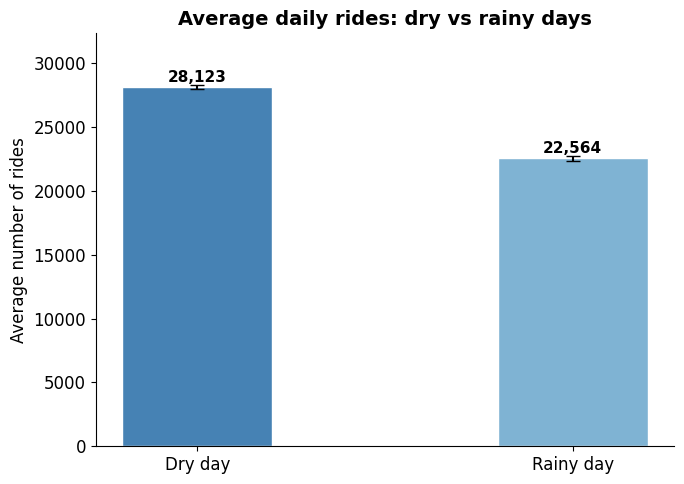

=== RAIN EFFECT ===
Dry days:   28,123 average rides
Rainy days: 22,564 average rides
Rain reduces rides by 19.8%
T-test p-value: 0.000000 (significant)


In [6]:
# %% Cell 6 — Plot 5: Rain effect
# Does rain reduce cycling?
# Compare rainy vs dry days

fig, ax = plt.subplots(figsize=(7, 5))

rain_avg = df.groupby('is_rainy')['rides'].agg(['mean', 'std', 'count'])
labels = ['Dry day', 'Rainy day']
colors = ['steelblue', '#7fb3d3']

bars = ax.bar(labels, rain_avg['mean'],
              yerr=rain_avg['std'] / np.sqrt(rain_avg['count']),
              color=colors, edgecolor='white',
              capsize=5, width=0.4)

for bar, val in zip(bars, rain_avg['mean']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 200,
            f'{val:,.0f}', ha='center', va='bottom',
            fontweight='bold', fontsize=11)

ax.set_title('Average daily rides: dry vs rainy days',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Average number of rides')
ax.set_ylim(0, rain_avg['mean'].max() * 1.15)
plt.tight_layout()
plt.savefig('../notebooks/plot_05_rain_effect.png', dpi=150, bbox_inches='tight')
plt.show()

dry_avg = rain_avg.loc[0, 'mean']
rainy_avg = rain_avg.loc[1, 'mean']
pct = (rainy_avg - dry_avg) / dry_avg * 100
print(f"=== RAIN EFFECT ===")
print(f"Dry days:   {dry_avg:,.0f} average rides")
print(f"Rainy days: {rainy_avg:,.0f} average rides")
print(f"Rain reduces rides by {abs(pct):.1f}%")

t_stat, p_val = stats.ttest_ind(
    df[df['is_rainy'] == 0]['rides'],
    df[df['is_rainy'] == 1]['rides']
)
print(f"T-test p-value: {p_val:.6f} ({'significant' if p_val < 0.05 else 'not significant'})")

C:\Users\jonas\AppData\Local\Temp\ipykernel_22976\79974364.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(season_data, labels=season_order, patch_artist=True,


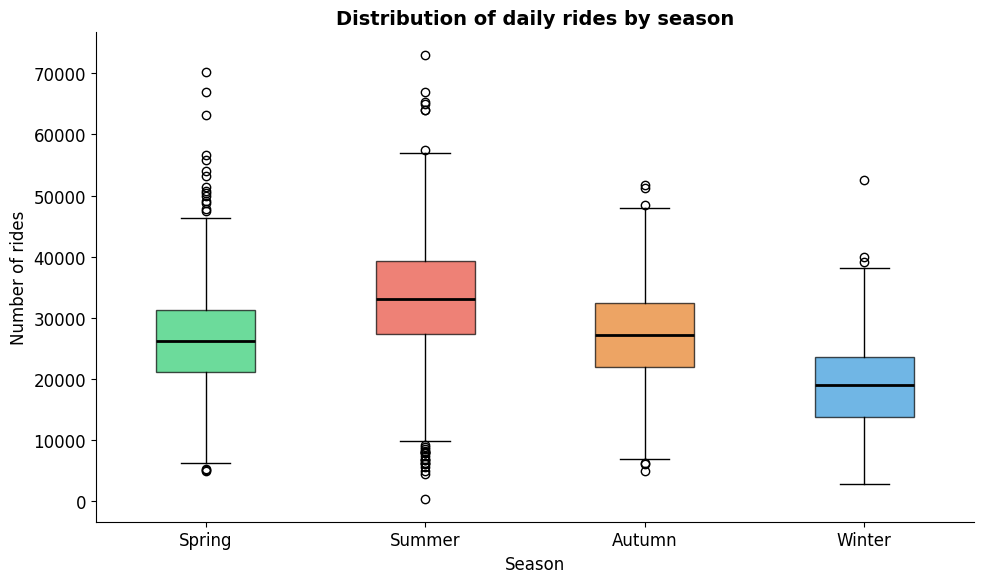

=== SEASON AVERAGES ===
                mean   median     std
season_name                          
Autumn       27040.0  27204.0  7538.0
Spring       26359.0  26179.0  8296.0
Summer       32768.0  33084.0  8878.0
Winter       18613.0  18874.0  6502.0


In [7]:
# %% Cell 7 — Plot 6: Season comparison box plot
# Box plots show not just the average but the full spread
# This is more informative than a simple bar chart
# and looks good in a report

fig, ax = plt.subplots(figsize=(10, 6))

season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
season_colors = ['#2ecc71', '#e74c3c', '#e67e22', '#3498db']

season_data = [df[df['season_name'] == s]['rides'].values 
               for s in season_order]

bp = ax.boxplot(season_data, labels=season_order, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))

for patch, color in zip(bp['boxes'], season_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Distribution of daily rides by season',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Number of rides')
plt.tight_layout()
plt.savefig('../notebooks/plot_06_season_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== SEASON AVERAGES ===")
print(df.groupby('season_name')['rides'].agg(['mean', 'median', 'std']).round(0))

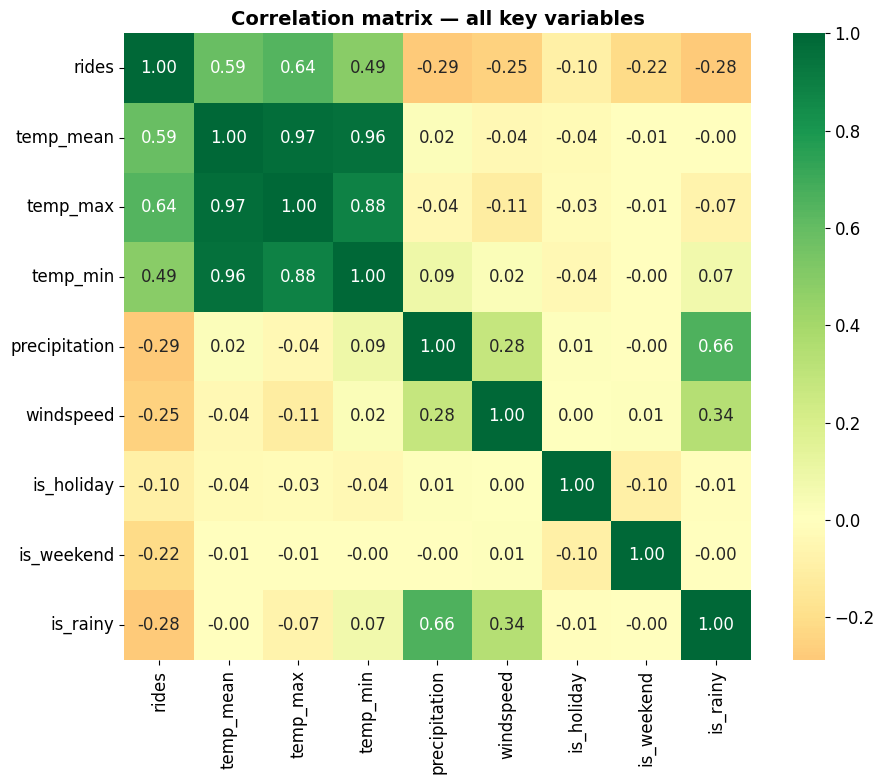

=== CORRELATIONS WITH RIDES ===
rides            1.000
temp_max         0.642
temp_mean        0.592
temp_min         0.491
is_holiday      -0.100
is_weekend      -0.215
windspeed       -0.248
is_rainy        -0.284
precipitation   -0.288
Name: rides, dtype: float64


In [8]:
# %% Cell 8 — Plot 7: Correlation heatmap
# Shows how all numerical variables relate to each other
# Especially useful to see which weather variables 
# correlate most strongly with rides

numeric_cols = ['rides', 'temp_mean', 'temp_max', 'temp_min',
                'precipitation', 'windspeed', 
                'is_holiday', 'is_weekend', 'is_rainy']

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='RdYlGn',
            center=0,
            ax=ax,
            square=True)

ax.set_title('Correlation matrix — all key variables',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/plot_07_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== CORRELATIONS WITH RIDES ===")
print(corr_matrix['rides'].sort_values(ascending=False).round(3))

In [9]:
# %% Cell 9 — Summary of all findings
print("=" * 55)
print("SUMMARY OF KEY FINDINGS")
print("=" * 55)

# Temperature
slope, intercept, r_value, p_value, _ = stats.linregress(
    df['temp_mean'], df['rides']
)
print(f"\nTEMPERATURE:")
print(f"  Each +1°C = +{slope:.0f} more rides per day")
print(f"  Correlation: r = {r_value:.3f}")
print(f"  Temperature explains {r_value**2*100:.1f}% of ride variation")

# Holiday
weekday_avg = df[df['day_type'] == 'Weekday']['rides'].mean()
holiday_avg = df[df['day_type'] == 'Holiday']['rides'].mean()
pct = (holiday_avg - weekday_avg) / weekday_avg * 100
print(f"\nHOLIDAYS:")
print(f"  Weekday average: {weekday_avg:,.0f} rides")
print(f"  Holiday average: {holiday_avg:,.0f} rides")
print(f"  Holidays have {pct:.1f}% rides vs normal weekdays")

# Season
print(f"\nSEASON:")
print(f"  Summer average: {df[df['season_name']=='Summer']['rides'].mean():,.0f}")
print(f"  Winter average: {df[df['season_name']=='Winter']['rides'].mean():,.0f}")
summer = df[df['season_name']=='Summer']['rides'].mean()
winter = df[df['season_name']=='Winter']['rides'].mean()
print(f"  Summer has {(summer-winter)/winter*100:.1f}% more rides than winter")

# Rain
dry = df[df['is_rainy']==0]['rides'].mean()
rainy = df[df['is_rainy']==1]['rides'].mean()
print(f"\nRAIN:")
print(f"  Dry days:   {dry:,.0f} rides")
print(f"  Rainy days: {rainy:,.0f} rides")
print(f"  Rain reduces rides by {(dry-rainy)/dry*100:.1f}%")

SUMMARY OF KEY FINDINGS

TEMPERATURE:
  Each +1°C = +994 more rides per day
  Correlation: r = 0.592
  Temperature explains 35.1% of ride variation

HOLIDAYS:
  Weekday average: 27,706 rides
  Holiday average: 20,111 rides
  Holidays have -27.4% rides vs normal weekdays

SEASON:
  Summer average: 32,768
  Winter average: 18,613
  Summer has 76.1% more rides than winter

RAIN:
  Dry days:   28,123 rides
  Rainy days: 22,564 rides
  Rain reduces rides by 19.8%


In [10]:
# Check yearly average rides to spot Covid impact
print("Average rides per year:")
print(df.groupby('year')['rides'].mean().round(0).to_string())

Average rides per year:
year
2010    14070.0
2011    19568.0
2012    26009.0
2013    22042.0
2014    27463.0
2015    27046.0
2016    28152.0
2017    28619.0
2018    28952.0
2019    28562.0
2020    28509.0
2021    29976.0
2022    31697.0
2023    23373.0
2024    23957.0
2025    24840.0
2026    18611.0
